## Nome: Mayara Cristina
## Matrícula:574

---

# Atividade 7 - Ajuste de Curvas Não Polinomial - HackTown

### Funções de Ajuste Não Polinomial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Modelo: Crescimento Logístico (Curva Sigmoide)
def modelo_nao_linear(t, L, k, t0):
    # L  = Limite máximo (Capacidade/Total de público)
    # k  = Taxa de adoção/viralização
    # t0 = Tempo de inflexão (onde o crescimento é mais rápido)
    return L / (1 + np.exp(-k * (t - t0)))

In [3]:
def plot_ajuste_nao_linear(ts, ys, popt, pontos_estimativa=None):
    """
    Plota a curva ajustada não linear a partir dos parâmetros otimizados.

    Parâmetros:
    -----------
    ts : array-like
        Pontos de medição de tempo.
    ys : array-like
        Valores medidos (ex: acessos simultâneos).
    popt : lista ou array
        Parâmetros otimizados obtidos (L, k, t0).
    pontos_estimativa : lista ou array, opcional
        Instantes de tempo para destacar estimativas no gráfico.
    """
    # Eixo denso para plotagem contínua da curva ajustada
    tt = np.linspace(min(ts), max(ts) + 10, 800)
    y_fit = modelo_nao_linear(tt, *popt)

    plt.figure(figsize=(9, 5))

    # Plota os dados reais do tráfego
    plt.scatter(ts, ys, label='Dados do Servidor (Reais)', color='blue', zorder=5)

    # Plota o modelo logístico ajustado
    plt.plot(tt, y_fit, label='Ajuste Não Polinomial (Logístico)', color='darkred', linewidth=2)

    # Marca pontos de estimativa caso fornecidos
    if pontos_estimativa is not None:
        pontos_estimativa = np.array(pontos_estimativa)
        y_est = modelo_nao_linear(pontos_estimativa, *popt)
        plt.scatter(pontos_estimativa, y_est, marker='x', s=90, color='green', label='Estimativas / Previsões', zorder=6)

    plt.xlabel('Tempo após Notificação Push (min)')
    plt.ylabel('Acessos Simultâneos no App')
    plt.title('Ajuste Não Polinomial — Tráfego de Rede no App HackTown')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


def ajustar_modelo(t, y, params0):
    """
    Ajusta o modelo não linear aos dados usando curve_fit (Mínimos Quadrados Não Lineares).
    """
    popt, _ = curve_fit(modelo_nao_linear, t, y, p0=params0)
    return popt # Retorna: L, k, t0

### Parte Prática

O **HackTown** é um festival de inovação de nível global numa cidade que cabe a pé (Santa Rita do Sapucaí). Durante o evento, a organização envia uma notificação *push* no aplicativo oficial anunciando uma "Palestra Surpresa com um ícone da tecnologia" em um hub específico.

A equipe de TI monitora o número de usuários abrindo o app simultaneamente. O tráfego não cresce como uma reta ou um polinômio simples; ele sofre um crescimento rápido (viral) que logo perde força e se estabiliza (já que há um limite de participantes no evento e o servidor possui limite de sockets).

Para prever o tráfego e evitar a queda do servidor, a equipe utiliza uma **Função Logística (Curva Sigmoide)**:

$$N(t) = \frac{L}{1 + e^{-k(t - t_0)}}$$

Onde:
* $L$ = Limite de público/capacidade máxima.
* $k$ = Taxa de aceleração (engajamento).
* $t_0$ = Tempo onde ocorre o maior pico de novos acessos (inflexão).

Os dados de acessos simultâneos registrados nos primeiros 20 minutos são:

| Tempo (min) | Acessos Simultâneos |
|---|---|
| 0 | 45 |
| 2 | 102 |
| 4 | 250 |
| 6 | 580 |
| 8 | 1300 |
| 10 | 2550 |
| 12 | 3700 |
| 14 | 4350 |
| 16 | 4790 |
| 18 | 4880 |
| 20 | 4980 |

Com base nesses dados, responda:

1. Utilize a função `ajustar_modelo` com estimativas iniciais $p_0 = [5500, 0.4, 12]$ para determinar os coeficientes otimizados do modelo ($L, k, t_0$).

In [4]:
# Dados fornecidos
t = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])

y = np.array([45, 102, 250, 580, 1300, 2550, 3700, 4350, 4790, 4880, 4980])

# Estimativas iniciais
p0 = [5500, 0.4, 12]

# Ajuste do modelo
popt = ajustar_modelo(t, y, p0)

# Separando os parâmetros encontrados
L, k, t0 = popt

print("L =", L)
print("k =", k)
print("t0 =", t0)

L = 4983.277767338201
k = 0.5080611891752458
t0 = 9.963732181552041


2. Estime o número de acessos nos instantes $t = 5\text{ min}$, $t = 15\text{ min}$ e faça uma previsão para $t = 25\text{ min}$ (arredonde para números inteiros).

In [5]:
# Tempos que queremos estimar
tempos_estimados = np.array([5, 15, 25])

# Calculando as estimativas com o modelo ajustado
acessos_estimados = modelo_nao_linear(tempos_estimados, *popt)

# Arredondando para números inteiros
acessos_estimados = np.round(acessos_estimados).astype(int)

print("Acessos em 5 min:", acessos_estimados[0])
print("Acessos em 15 min:", acessos_estimados[1])
print("Acessos em 25 min:", acessos_estimados[2])

Acessos em 5 min: 370
Acessos em 15 min: 4625
Acessos em 25 min: 4981


3. Plote um gráfico contendo os pontos reais de tráfego, a curva ajustada do modelo não linear e os pontos estimados destacando a previsão futura.

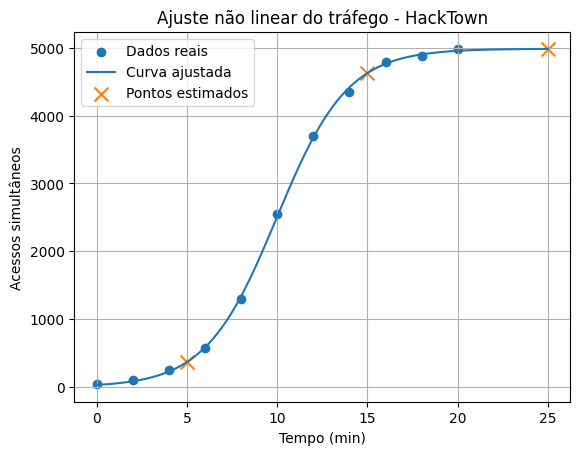

In [6]:
import matplotlib.pyplot as plt

# Criando vários pontos de tempo para desenhar a curva
t_curva = np.linspace(0, 25, 200)

# Calculando a curva ajustada
y_curva = modelo_nao_linear(t_curva, *popt)

# Gráfico
plt.scatter(t, y, label='Dados reais')

plt.plot(t_curva, y_curva, label='Curva ajustada')

plt.scatter(
    tempos_estimados,
    acessos_estimados,
    marker='x',
    s=100,
    label='Pontos estimados'
)

plt.xlabel('Tempo (min)')
plt.ylabel('Acessos simultâneos')
plt.title('Ajuste não linear do tráfego - HackTown')

plt.legend()
plt.grid()

plt.show()

### Parte Teórica

1. Por que em problemas reais de tecnologia (como a previsão de acessos simultâneos em um servidor) prefere-se utilizar um modelo logístico (sigmoide) em vez de ajustar um polinômio de grau elevado (ex: grau 8)?

**Resposta:**
O parâmetro L representa o limite máximo de acessos simultâneos que o modelo prevê. Nesse caso, aproximadamente 4.983 acessos.



2. Diferencie o conceito de **Interpolação** do conceito de **Ajuste de Curvas por Mínimos Quadrados** (Regressão). Em dados de tráfego de rede (com flutuações e atrasos normais), qual método deve ser escolhido?

**Resposta:**
Interpolação: cria uma curva que passa exatamente por todos os pontos.
Mínimos Quadrados (Regressão): busca uma curva que melhor represente os dados, sem precisar passar exatamente por todos eles.

Para dados de tráfego de rede, deve-se usar Mínimos Quadrados, pois existem flutuações e atrasos nos dados.
